# TimescaleDB: `patch` & `pred_patch` Tables with Continuous Aggregate

1. Create `patch` (regular table) and `pred_patch` (TimescaleDB hypertable, partitioned on `event_ts`)
2. Insert 1 000 rows into each table
3. Create a TimescaleDB continuous aggregate that joins the two tables and groups by `pred_label`, `gt_label`, `grid_cell_id`

In [27]:
import psycopg2
import time

DATABASE_URL = "dbname=testdb user=testuser password=mypassword host=prototyping-tsdb-1"
N_ROWS = 100000  # number of rows to insert into each table

conn = psycopg2.connect(DATABASE_URL)
conn.autocommit = False
cur = conn.cursor()

# Verify TimescaleDB is available
cur.execute("SELECT extversion FROM pg_extension WHERE extname = 'timescaledb';")
row = cur.fetchone()
print(f"TimescaleDB version: {row[0] if row else 'NOT INSTALLED'}")

TimescaleDB version: 2.25.2


## 1. Create Tables

- **`patch`** — regular table holding ground-truth labels per patch.  
- **`pred_patch`** — TimescaleDB hypertable partitioned by `event_ts`, holding per-inference predictions.

In [28]:
# ── Drop existing objects (clean slate) ──────────────────────────────────────
cur.execute("DROP MATERIALIZED VIEW IF EXISTS pred_patch_label_agg CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS cell_to_parent(BIGINT, INT) CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS morton_encode(BIGINT, BIGINT) CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS morton_decode_j(BIGINT) CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS morton_decode_i(BIGINT) CASCADE;")
cur.execute("DROP TABLE IF EXISTS pred_patch CASCADE;")
cur.execute("DROP TABLE IF EXISTS patch CASCADE;")
conn.commit()

# ── patch table (regular) ─────────────────────────────────────────────────────
cur.execute("""
    CREATE TABLE patch (
        id          BIGSERIAL    PRIMARY KEY,
        patch_uid   INT          NOT NULL UNIQUE,
        gt_label    INT,
        event_ts    TIMESTAMPTZ  NOT NULL DEFAULT NOW(),
        image_id    INT,
        working_mag FLOAT
    );
""")

# ── pred_patch table (will become a hypertable) ───────────────────────────────
# grid_cell_id is BIGINT to hold the 64-bit Z-order encoded cell index
cur.execute("""
    CREATE TABLE pred_patch (
        id           BIGSERIAL   NOT NULL,
        patch_uid    BIGINT      NOT NULL,
        embed_coords POINT,
        grid_cell_id BIGINT,
        event_ts     TIMESTAMPTZ NOT NULL DEFAULT NOW(),
        pred_label   INT,
        patch_coords POINT,
        PRIMARY KEY (id, event_ts)          -- event_ts must be in the PK for hypertable
    );
""")
conn.commit()

# ── Convert pred_patch to a TimescaleDB hypertable ────────────────────────────
cur.execute("""
    SELECT create_hypertable('pred_patch', 'event_ts', chunk_time_interval => INTERVAL '1 day');
""")
conn.commit()
print("Tables created. pred_patch is now a hypertable partitioned on event_ts.")

Tables created. pred_patch is now a hypertable partitioned on event_ts.


## 2. Insert 1 000 Rows

`patch_uid` values 1–1 000 are shared across both tables so they can be joined later.

In [29]:
# ── Insert N_ROWS rows into patch ────────────────────────────────────────────
# patch_uid : 1 – N_ROWS
# gt_label  : 0 – 4  (5 classes, deterministic via modulo so joins are meaningful)
# image_id  : 1 – 10
# working_mag: 10.0 / 20.0 / 40.0 cycling
# event_ts  : spread over the last 30 days

start = time.time()
cur.execute(f"""
    INSERT INTO patch (patch_uid, gt_label, event_ts, image_id, working_mag)
    SELECT
        gs                                                   AS patch_uid,
        gs % 5                                               AS gt_label,
        NOW() - (random() * INTERVAL '30 days')             AS event_ts,
        (gs % 10) + 1                                        AS image_id,
        CASE (gs % 3)
            WHEN 0 THEN 10.0
            WHEN 1 THEN 20.0
            ELSE        40.0
        END                                                  AS working_mag
    FROM generate_series(1, {N_ROWS}) AS gs;
""")
conn.commit()
print(f"patch: {N_ROWS:,} rows inserted in {time.time() - start:.3f}s")

patch: 100,000 rows inserted in 0.388s


In [30]:
# ── Insert N_ROWS rows into pred_patch ──────────────────────────────────────
# patch_uid    : 1 – N_ROWS  (matches patch table)
# pred_label   : 0 – 4  (5 classes)
# grid_cell_id : Z-order encoded cell at level 5
#                  i = gs % 8  (0–7), j = (gs / 8) % 8  (0–7)  → 64 distinct level-5 cells
# embed_coords : random POINT in [0, 100) x [0, 100)
# patch_coords : random POINT in [0, 1000) x [0, 1000)
# event_ts     : spread over the last 7 days (determines hypertable chunks)
#
# Z-order cell encoding (matches HierarchicalGridIndexZOrder in utils.py):
#   bits 63-58 = level (6 bits)
#   bits 57-0  = Morton code – i bits at even positions, j bits at odd positions

GRID_LEVEL = 5

start = time.time()
cur.execute(f"""
    INSERT INTO pred_patch (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
    SELECT
        gs                                                            AS patch_uid,
        POINT(random() * 100, random() * 100)                         AS embed_coords,
        -- Encode level-{GRID_LEVEL} Z-order cell: interleave i and j bit-by-bit
        -- i = gs % 8 (3 bits), j = (gs / 8) % 8 (3 bits)
        -- Morton bits 0..5: i0,j0, i1,j1, i2,j2
        (({GRID_LEVEL}::BIGINT) << 58)
        | (  (( (gs % 8)         & 1))
           | ((((gs % 8) >> 1)   & 1) << 2)
           | ((((gs % 8) >> 2)   & 1) << 4)
           | ((((gs / 8) % 8     & 1)) << 1)
           | (((((gs / 8) % 8) >> 1) & 1) << 3)
           | (((((gs / 8) % 8) >> 2) & 1) << 5)
          )::BIGINT                                                    AS grid_cell_id,
        NOW() - (random() * INTERVAL '7 days')                        AS event_ts,
        gs % 5                                                         AS pred_label,
        POINT(random() * 1000, random() * 1000)                       AS patch_coords
    FROM generate_series(1, {N_ROWS}) AS gs;
""")
conn.commit()
print(f"pred_patch: {N_ROWS:,} rows inserted in {time.time() - start:.3f}s")

# Quick sanity check
cur.execute("SELECT COUNT(*) FROM patch;")
print(f"  patch row count      : {cur.fetchone()[0]:,}")
cur.execute("SELECT COUNT(*) FROM pred_patch;")
print(f"  pred_patch row count : {cur.fetchone()[0]:,}")
cur.execute("SELECT COUNT(DISTINCT grid_cell_id) FROM pred_patch;")
print(f"  distinct level-{GRID_LEVEL} cells : {cur.fetchone()[0]:,}")

# Show hypertable chunks
cur.execute("""
    SELECT chunk_name, range_start, range_end
    FROM timescaledb_information.chunks
    WHERE hypertable_name = 'pred_patch'
    ORDER BY range_start;
""")
chunks = cur.fetchall()
print(f"\npred_patch hypertable chunks ({len(chunks)} total):")
for c in chunks:
    print(f"  {c[0]}  {c[1]}  →  {c[2]}")

pred_patch: 100,000 rows inserted in 0.593s
  patch row count      : 100,000
  pred_patch row count : 100,000
  distinct level-5 cells : 64

pred_patch hypertable chunks (8 total):
  _hyper_37_110_chunk  2026-02-25 00:00:00+00:00  →  2026-02-26 00:00:00+00:00
  _hyper_37_108_chunk  2026-02-26 00:00:00+00:00  →  2026-02-27 00:00:00+00:00
  _hyper_37_105_chunk  2026-02-27 00:00:00+00:00  →  2026-02-28 00:00:00+00:00
  _hyper_37_107_chunk  2026-02-28 00:00:00+00:00  →  2026-03-01 00:00:00+00:00
  _hyper_37_103_chunk  2026-03-01 00:00:00+00:00  →  2026-03-02 00:00:00+00:00
  _hyper_37_106_chunk  2026-03-02 00:00:00+00:00  →  2026-03-03 00:00:00+00:00
  _hyper_37_104_chunk  2026-03-03 00:00:00+00:00  →  2026-03-04 00:00:00+00:00
  _hyper_37_109_chunk  2026-03-04 00:00:00+00:00  →  2026-03-05 00:00:00+00:00


## 3. Continuous Aggregate

Create a TimescaleDB continuous aggregate that **joins `pred_patch` (hypertable) with `patch`** and rolls up counts for every unique `(bucket, pred_label, gt_label, grid_cell_id)` combination.

`time_bucket` is mandatory for TimescaleDB continuous aggregates; here we use a 1-hour bucket.  
JOINs with regular (non-hypertable) tables are supported since TimescaleDB 2.9.

In [31]:
# ── Create the continuous aggregate ──────────────────────────────────────────
# Each row = one time bucket × pred_label × gt_label × grid_cell_id
# The JOIN on patch_uid brings gt_label from the patch table into the aggregate.

cur.execute("""
    CREATE MATERIALIZED VIEW pred_patch_label_agg
    WITH (timescaledb.continuous) AS
    SELECT
        time_bucket('5 seconds', pp.event_ts)  AS bucket,
        pp.pred_label,
        p.gt_label,
        pp.grid_cell_id,
        COUNT(*)                               AS patch_count
    FROM pred_patch  pp
    JOIN patch       p  ON p.patch_uid = pp.patch_uid
    GROUP BY 1, 2, 3, 4
    WITH NO DATA;
""")
conn.commit()
print("Continuous aggregate 'pred_patch_label_agg' created.")

# ── Manually refresh to materialise existing data ─────────────────────────────
# refresh_continuous_aggregate() must run outside a transaction block
conn.autocommit = True
cur.execute("""
    CALL refresh_continuous_aggregate(
        'pred_patch_label_agg',
        NOW() - INTERVAL '8 days',
        NOW() + INTERVAL '10 seconds'
    );
""")
conn.autocommit = False
print("Continuous aggregate refreshed.")

# ── Optional: enable automatic background refresh policy ─────────────────────
cur.execute("""
    SELECT add_continuous_aggregate_policy(
        'pred_patch_label_agg',
        start_offset      => INTERVAL '8 days',
        end_offset        => INTERVAL '5 seconds',
        schedule_interval => INTERVAL '5 seconds'
    );
""")
conn.commit()
print("Refresh policy added (runs every 5 seconds, lags by one bucket).")

Continuous aggregate 'pred_patch_label_agg' created.
Continuous aggregate refreshed.
Refresh policy added (runs every 5 seconds, lags by one bucket).


## 4. Morton SQL Helper Functions

Pure-SQL implementations of the Z-order (Morton) encode/decode and `cell_to_parent` operations,
mirroring `HierarchicalGridIndexZOrder` in `utils.py`.

These are `IMMUTABLE` functions so the continuous aggregates can call them inline without any per-row overhead.

| Function | Purpose |
|---|---|
| `morton_decode_i(code)` | Extract i (column) coordinate from a 58-bit Morton code |
| `morton_decode_j(code)` | Extract j (row) coordinate from a 58-bit Morton code |
| `morton_encode(i, j)` | Interleave i and j bits into a 58-bit Morton code |
| `cell_to_parent(cell, parent_level)` | Return the ancestor cell at a coarser resolution |

In [32]:
# TimescaleDB's refresh procedure runs with a restricted search_path
# (e.g. _timescaledb_internal, pg_catalog), so SQL functions called from a
# continuous aggregate VIEW definition must explicitly pin search_path = public
# to ensure their own sub-function calls resolve correctly during inlining.

# ── Morton decode: extract i (even bits 0,2,4,...,56) ────────────────────────
cur.execute("""
CREATE OR REPLACE FUNCTION morton_decode_i(code BIGINT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
          ((code >>  0) & 1)
        | (((code >>  2) & 1) <<  1) | (((code >>  4) & 1) <<  2)
        | (((code >>  6) & 1) <<  3) | (((code >>  8) & 1) <<  4)
        | (((code >> 10) & 1) <<  5) | (((code >> 12) & 1) <<  6)
        | (((code >> 14) & 1) <<  7) | (((code >> 16) & 1) <<  8)
        | (((code >> 18) & 1) <<  9) | (((code >> 20) & 1) << 10)
        | (((code >> 22) & 1) << 11) | (((code >> 24) & 1) << 12)
        | (((code >> 26) & 1) << 13) | (((code >> 28) & 1) << 14)
        | (((code >> 30) & 1) << 15) | (((code >> 32) & 1) << 16)
        | (((code >> 34) & 1) << 17) | (((code >> 36) & 1) << 18)
        | (((code >> 38) & 1) << 19) | (((code >> 40) & 1) << 20)
        | (((code >> 42) & 1) << 21) | (((code >> 44) & 1) << 22)
        | (((code >> 46) & 1) << 23) | (((code >> 48) & 1) << 24)
        | (((code >> 50) & 1) << 25) | (((code >> 52) & 1) << 26)
        | (((code >> 54) & 1) << 27) | (((code >> 56) & 1) << 28)
    )::BIGINT
$$;
""")

# ── Morton decode: extract j (odd bits 1,3,5,...,57) ─────────────────────────
cur.execute("""
CREATE OR REPLACE FUNCTION morton_decode_j(code BIGINT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
          ((code >>  1) & 1)
        | (((code >>  3) & 1) <<  1) | (((code >>  5) & 1) <<  2)
        | (((code >>  7) & 1) <<  3) | (((code >>  9) & 1) <<  4)
        | (((code >> 11) & 1) <<  5) | (((code >> 13) & 1) <<  6)
        | (((code >> 15) & 1) <<  7) | (((code >> 17) & 1) <<  8)
        | (((code >> 19) & 1) <<  9) | (((code >> 21) & 1) << 10)
        | (((code >> 23) & 1) << 11) | (((code >> 25) & 1) << 12)
        | (((code >> 27) & 1) << 13) | (((code >> 29) & 1) << 14)
        | (((code >> 31) & 1) << 15) | (((code >> 33) & 1) << 16)
        | (((code >> 35) & 1) << 17) | (((code >> 37) & 1) << 18)
        | (((code >> 39) & 1) << 19) | (((code >> 41) & 1) << 20)
        | (((code >> 43) & 1) << 21) | (((code >> 45) & 1) << 22)
        | (((code >> 47) & 1) << 23) | (((code >> 49) & 1) << 24)
        | (((code >> 51) & 1) << 25) | (((code >> 53) & 1) << 26)
        | (((code >> 55) & 1) << 27) | (((code >> 57) & 1) << 28)
    )::BIGINT
$$;
""")

# ── Morton encode: interleave i (even bits) and j (odd bits) ─────────────────
cur.execute("""
CREATE OR REPLACE FUNCTION morton_encode(i BIGINT, j BIGINT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
          ((i & 1))              | ((j & 1) << 1)
        | (((i >>  1) & 1) <<  2) | (((j >>  1) & 1) <<  3)
        | (((i >>  2) & 1) <<  4) | (((j >>  2) & 1) <<  5)
        | (((i >>  3) & 1) <<  6) | (((j >>  3) & 1) <<  7)
        | (((i >>  4) & 1) <<  8) | (((j >>  4) & 1) <<  9)
        | (((i >>  5) & 1) << 10) | (((j >>  5) & 1) << 11)
        | (((i >>  6) & 1) << 12) | (((j >>  6) & 1) << 13)
        | (((i >>  7) & 1) << 14) | (((j >>  7) & 1) << 15)
        | (((i >>  8) & 1) << 16) | (((j >>  8) & 1) << 17)
        | (((i >>  9) & 1) << 18) | (((j >>  9) & 1) << 19)
        | (((i >> 10) & 1) << 20) | (((j >> 10) & 1) << 21)
        | (((i >> 11) & 1) << 22) | (((j >> 11) & 1) << 23)
        | (((i >> 12) & 1) << 24) | (((j >> 12) & 1) << 25)
        | (((i >> 13) & 1) << 26) | (((j >> 13) & 1) << 27)
        | (((i >> 14) & 1) << 28) | (((j >> 14) & 1) << 29)
        | (((i >> 15) & 1) << 30) | (((j >> 15) & 1) << 31)
        | (((i >> 16) & 1) << 32) | (((j >> 16) & 1) << 33)
        | (((i >> 17) & 1) << 34) | (((j >> 17) & 1) << 35)
        | (((i >> 18) & 1) << 36) | (((j >> 18) & 1) << 37)
        | (((i >> 19) & 1) << 38) | (((j >> 19) & 1) << 39)
        | (((i >> 20) & 1) << 40) | (((j >> 20) & 1) << 41)
        | (((i >> 21) & 1) << 42) | (((j >> 21) & 1) << 43)
        | (((i >> 22) & 1) << 44) | (((j >> 22) & 1) << 45)
        | (((i >> 23) & 1) << 46) | (((j >> 23) & 1) << 47)
        | (((i >> 24) & 1) << 48) | (((j >> 24) & 1) << 49)
        | (((i >> 25) & 1) << 50) | (((j >> 25) & 1) << 51)
        | (((i >> 26) & 1) << 52) | (((j >> 26) & 1) << 53)
        | (((i >> 27) & 1) << 54) | (((j >> 27) & 1) << 55)
        | (((i >> 28) & 1) << 56) | (((j >> 28) & 1) << 57)
    )::BIGINT
$$;
""")

# ── cell_to_parent: coarsen a Z-order cell to a lower resolution level ────────
# SET search_path ensures morton_decode_i/j and morton_encode are found even
# when called from a TimescaleDB refresh context with a restricted search_path.
cur.execute("""
CREATE OR REPLACE FUNCTION cell_to_parent(cell BIGINT, parent_level INT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
        (parent_level::BIGINT << 58)
        | morton_encode(
            morton_decode_i(cell & 288230376151711743::BIGINT) >> ((cell >> 58)::INT - parent_level),
            morton_decode_j(cell & 288230376151711743::BIGINT) >> ((cell >> 58)::INT - parent_level)
          )
    )
$$;
""")
conn.commit()
print("Morton SQL functions created (with search_path = public):")
print("  morton_decode_i, morton_decode_j, morton_encode, cell_to_parent")

# ── Smoke test: level-5 cell with i=3, j=2 ───────────────────────────────────
cur.execute("""
    SELECT
        cell_val,
        cell_val >> 58                                          AS level,
        morton_decode_i(cell_val & 288230376151711743::BIGINT)  AS i,
        morton_decode_j(cell_val & 288230376151711743::BIGINT)  AS j,
        cell_to_parent(cell_val, 3)                             AS parent_l3,
        cell_to_parent(cell_val, 1)                             AS parent_l1,
        cell_to_parent(cell_val, 0)                             AS parent_l0
    FROM (SELECT (5::BIGINT << 58) | morton_encode(3, 2) AS cell_val) t;
""")
r = cur.fetchone()
print(f"\nSmoke test  cell={r[0]}  level={r[1]}  i={r[2]}  j={r[3]}")
print(f"  parent@level3 = {r[4]}")
print(f"  parent@level1 = {r[5]}")
print(f"  parent@level0 = {r[6]}")

Morton SQL functions created (with search_path = public):
  morton_decode_i, morton_decode_j, morton_encode, cell_to_parent

Smoke test  cell=1441151880758558733  level=5  i=3  j=2
  parent@level3 = 864691128455135232
  parent@level1 = 288230376151711744
  parent@level0 = 0


## 5. Hierarchical Rollup Continuous Aggregates

Each level is a **hierarchical CAgg** built on top of the previous one.
`cell_to_parent(grid_cell_id, target_level)` maps each fine-grained Z-order cell to its ancestor purely via bitwise arithmetic — no lookup table needed.

| View | Source | Spatial level | Time bucket |
|---|---|---|---|
| `pred_patch_label_agg` | raw hypertable | 5 (finest) | 1 hour |
| `pred_patch_label_agg_l3` | l5 CAgg | 3 | 1 day |
| `pred_patch_label_agg_l1` | l3 CAgg | 1 | 1 day |
| `pred_patch_label_agg_l0` | l1 CAgg | 0 (coarsest) | 7 days |

In [33]:
# ── Rollup specification ──────────────────────────────────────────────────────
# Fields: (view_name, source_view, time_bucket, target_level, start_back, end_forward)
#
#   start_back   – how far back to refresh (covers many 5-second buckets)
#   end_forward  – must be ≥ 2 × bucket width so TimescaleDB sees ≥2 bucket boundaries
ROLLUP_LEVELS = [
    ("pred_patch_label_agg_l3", "pred_patch_label_agg",    "5 seconds", 3, "8 days", "10 seconds"),
    ("pred_patch_label_agg_l1", "pred_patch_label_agg_l3", "5 seconds", 1, "8 days", "10 seconds"),
    ("pred_patch_label_agg_l0", "pred_patch_label_agg_l1", "5 seconds", 0, "8 days", "10 seconds"),
]

# ── Drop any existing rollup views (cascade to clear stale policies) ──────────
for view_name, *_ in reversed(ROLLUP_LEVELS):
    cur.execute(f"DROP MATERIALIZED VIEW IF EXISTS {view_name} CASCADE;")
conn.commit()

# ── Create hierarchical CAggs ─────────────────────────────────────────────────
for view_name, source, bucket, tgt_level, *_ in ROLLUP_LEVELS:
    cur.execute(f"""
        CREATE MATERIALIZED VIEW {view_name}
        WITH (timescaledb.continuous, timescaledb.materialized_only = false) AS
        SELECT
            time_bucket(INTERVAL '{bucket}', bucket)      AS bucket,
            pred_label,
            gt_label,
            cell_to_parent(grid_cell_id, {tgt_level})     AS grid_cell_id,
            SUM(patch_count)                               AS patch_count
        FROM {source}
        GROUP BY 1, 2, 3, 4
        WITH NO DATA;
    """)
    conn.commit()
    print(f"Created '{view_name}'  source={source}  bucket={bucket}  level={tgt_level}")

# ── Refresh all rollup views (must run outside a transaction block) ───────────
conn.autocommit = True
for view_name, _, _, _, start_back, end_fwd in ROLLUP_LEVELS:
    cur.execute(f"""
        CALL refresh_continuous_aggregate(
            '{view_name}',
            NOW() - INTERVAL '{start_back}',
            NOW() + INTERVAL '{end_fwd}'
        );
    """)
    print(f"Refreshed '{view_name}'")
conn.autocommit = False

# ── Add automatic refresh policies ───────────────────────────────────────────
for view_name, _, bucket, _, start_back, _ in ROLLUP_LEVELS:
    cur.execute(f"""
        SELECT add_continuous_aggregate_policy(
            '{view_name}',
            start_offset      => INTERVAL '{start_back}',
            end_offset        => INTERVAL '{bucket}',
            schedule_interval => INTERVAL '{bucket}'
        );
    """)
conn.commit()
print("\nRefresh policies added for all rollup levels.")

Created 'pred_patch_label_agg_l3'  source=pred_patch_label_agg  bucket=5 seconds  level=3
Created 'pred_patch_label_agg_l1'  source=pred_patch_label_agg_l3  bucket=5 seconds  level=1
Created 'pred_patch_label_agg_l0'  source=pred_patch_label_agg_l1  bucket=5 seconds  level=0
Refreshed 'pred_patch_label_agg_l3'
Refreshed 'pred_patch_label_agg_l1'
Refreshed 'pred_patch_label_agg_l0'

Refresh policies added for all rollup levels.


## 6. Verify All Levels

Query each CAgg and confirm that:
- Row counts decrease as we coarsen (fewer distinct cells at lower levels)
- `SUM(patch_count)` is **identical** across all levels (no data loss during rollup)

In [34]:
ALL_VIEWS = [
    ("pred_patch_label_agg",    "level 5 (finest)", "5 seconds"),
    ("pred_patch_label_agg_l3", "level 3",          "5 seconds"),
    ("pred_patch_label_agg_l1", "level 1",          "5 seconds"),
    ("pred_patch_label_agg_l0", "level 0 (coarsest)", "5 seconds"),
]

print(f"{'View':<30}  {'level':<16}  {'bucket':>10}  {'rows':>6}  {'cells':>6}  {'total_patches':>14}")
print("-" * 90)

for view_name, label, bucket in ALL_VIEWS:
    cur.execute(f"""
        SELECT
            COUNT(*)                  AS total_rows,
            COUNT(DISTINCT grid_cell_id) AS distinct_cells,
            SUM(patch_count)          AS total_patches
        FROM {view_name};
    """)
    total_rows, distinct_cells, total_patches = cur.fetchone()
    print(f"{view_name:<30}  {label:<16}  {bucket:>10}  {total_rows:>6,}  {distinct_cells:>6,}  {total_patches:>14,}")

# ── Show 5 sample rows from each rollup level ─────────────────────────────────
for view_name, label, _ in ALL_VIEWS:   # skip base level, already shown above
    cur.execute(f"""
        SELECT bucket, pred_label, gt_label,
               grid_cell_id >> 58          AS cell_level,
               grid_cell_id,
               patch_count
        FROM {view_name}
        ORDER BY bucket DESC, grid_cell_id, pred_label, gt_label
        LIMIT 5;
    """)
    rows = cur.fetchall()
    print(f"\n{view_name}  [{label}]  — sample rows:")
    print(f"  {'bucket':<27} {'pred':>4}  {'gt':>4}  {'lvl':>4}  {'cell_id':>20}  {'count':>6}")
    print(f"  {'-'*75}")
    for r in rows:
        print(f"  {str(r[0]):<27} {r[1]:>4}  {r[2]:>4}  {r[3]:>4}  {r[4]:>20}  {r[5]:>6}")

View                            level                 bucket    rows   cells   total_patches
------------------------------------------------------------------------------------------
pred_patch_label_agg            level 5 (finest)   5 seconds  99,874      64         100,000
pred_patch_label_agg_l3         level 3            5 seconds  98,030       4         100,000
pred_patch_label_agg_l1         level 1            5 seconds  92,246       1         100,000
pred_patch_label_agg_l0         level 0 (coarsest)   5 seconds  92,246       1         100,000

pred_patch_label_agg  [level 5 (finest)]  — sample rows:
  bucket                      pred    gt   lvl               cell_id   count
  ---------------------------------------------------------------------------
  2026-03-04 23:23:30+00:00      2     2     5   1441151880758558750       1
  2026-03-04 23:23:30+00:00      2     2     5   1441151880758558760       1
  2026-03-04 23:23:20+00:00      2     2     5   1441151880758558747       

## 7. Spatial & Temporal Visualizations

Use `HierarchicalGridIndexZOrder` to convert each `grid_cell_id` back to real spatial coordinates, then render:

1. **Spatial heatmap** — `patch_count` per cell footprint drawn at all four resolution levels  
2. **Cell coarsening cascade** — one column of cells with their parent hierarchy overlaid  
3. **Time series** — total patches per 5-second bucket for each level  
4. **Rollup conservation** — bar chart verifying `SUM(patch_count)` is identical at every level

In [35]:
import sys
sys.path.insert(0, '/opt/PatchSorter/prototyping')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import psycopg2
from utils import HierarchicalGridIndexZOrder

# ── Reconnect (avoids depending on the state of conn/cur in earlier cells) ────
_vis_conn = psycopg2.connect(DATABASE_URL)
_vis_cur  = _vis_conn.cursor()

# cell_size=1.0 matches the insertion logic in cell 7 (same default as utils.py)
grid = HierarchicalGridIndexZOrder(cell_size=1.0)

VIEWS = [
    ("pred_patch_label_agg",    5, "Level 5 (base)"),
    ("pred_patch_label_agg_l3", 3, "Level 3"),
    ("pred_patch_label_agg_l1", 1, "Level 1"),
    ("pred_patch_label_agg_l0", 0, "Level 0 (coarsest)"),
]

# ── Spatial: SUM(patch_count) per distinct grid_cell_id ──────────────────────
spatial_data = {}
for view, level, label in VIEWS:
    _vis_cur.execute(f"""
        SELECT grid_cell_id, SUM(patch_count)::int
        FROM {view}
        GROUP BY grid_cell_id;
    """)
    spatial_data[view] = _vis_cur.fetchall()

# ── Temporal: total patches per time bucket ───────────────────────────────────
timeseries_data = {}
for view, level, label in VIEWS:
    _vis_cur.execute(f"""
        SELECT bucket, SUM(patch_count)::int
        FROM {view}
        GROUP BY bucket
        ORDER BY bucket;
    """)
    timeseries_data[view] = _vis_cur.fetchall()

print(f"{'View':<35}  {'cells':>5}  {'buckets':>7}  {'total_patches':>14}")
print("-" * 65)
for view, level, label in VIEWS:
    n_cells   = len(spatial_data[view])
    n_buckets = len(timeseries_data[view])
    total     = sum(r[1] for r in spatial_data[view])
    print(f"{label:<35}  {n_cells:>5}  {n_buckets:>7,}  {total:>14,}")

View                                 cells  buckets   total_patches
-----------------------------------------------------------------
Level 5 (base)                          64   68,156         100,000
Level 3                                  4   68,156         100,000
Level 1                                  1   68,156         100,000
Level 0 (coarsest)                       1   68,156         100,000


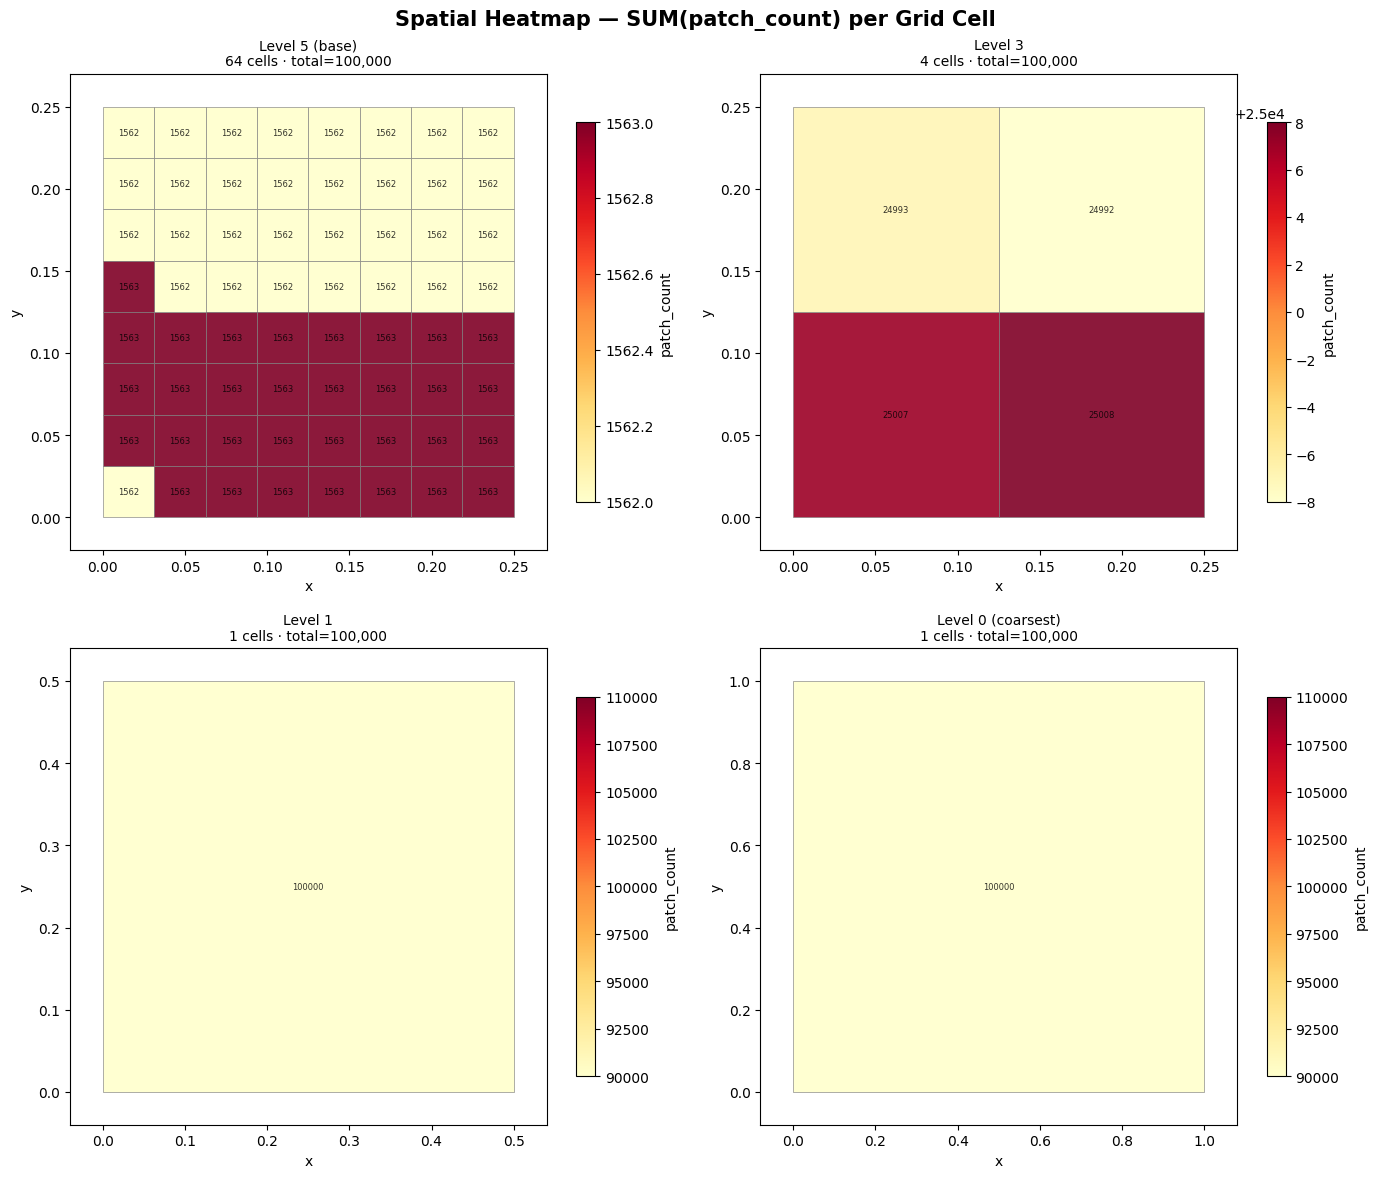

In [36]:
# ── Helper: convert a cell_id to a closed polygon (xs, ys) ───────────────────
def cell_polygon(cell_id):
    """Return (xs, ys) lists for use with ax.fill / ax.plot."""
    pts = grid.cell_to_boundary(cell_id)   # returns closed polygon
    return [p[0] for p in pts], [p[1] for p in pts]

# ── Helper: compute axis bounds for a collection of cell_ids ─────────────────
def view_bounds(rows, pad_frac=0.08):
    all_pts = [pt for cell_id, _ in rows for pt in grid.cell_to_boundary(cell_id)]
    xs = [p[0] for p in all_pts]
    ys = [p[1] for p in all_pts]
    w  = max(xs) - min(xs) or grid.cell_size
    h  = max(ys) - min(ys) or grid.cell_size
    return (min(xs) - w * pad_frac, max(xs) + w * pad_frac,
            min(ys) - h * pad_frac, max(ys) + h * pad_frac)

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — 2×2 Spatial Heatmap: patch_count per cell footprint, all levels
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Spatial Heatmap — SUM(patch_count) per Grid Cell", fontsize=15, fontweight="bold")

for ax, (view, level, label) in zip(axes.flat, VIEWS):
    rows = spatial_data[view]
    if not rows:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label)
        continue

    counts       = [r[1] for r in rows]
    norm         = mcolors.Normalize(vmin=min(counts), vmax=max(counts))
    cmap         = cm.YlOrRd
    x0, x1, y0, y1 = view_bounds(rows)

    for cell_id, count in rows:
        xs, ys = cell_polygon(cell_id)
        ax.fill(xs, ys, color=cmap(norm(count)), edgecolor="gray", linewidth=0.5, alpha=0.9)
        # label the cell with its count if there's enough room
        cx, cy = grid.cell_to_point(cell_id)
        if (x1 - x0) / max(len(set(r[0] >> 58 for r in rows)), 1) > 0:
            ax.text(cx, cy, str(count), ha="center", va="center",
                    fontsize=6, color="black", alpha=0.8)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    ax.set_title(f"{label}\n{len(rows)} cells · total={sum(counts):,}", fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.75, label="patch_count")

plt.tight_layout()
plt.show()

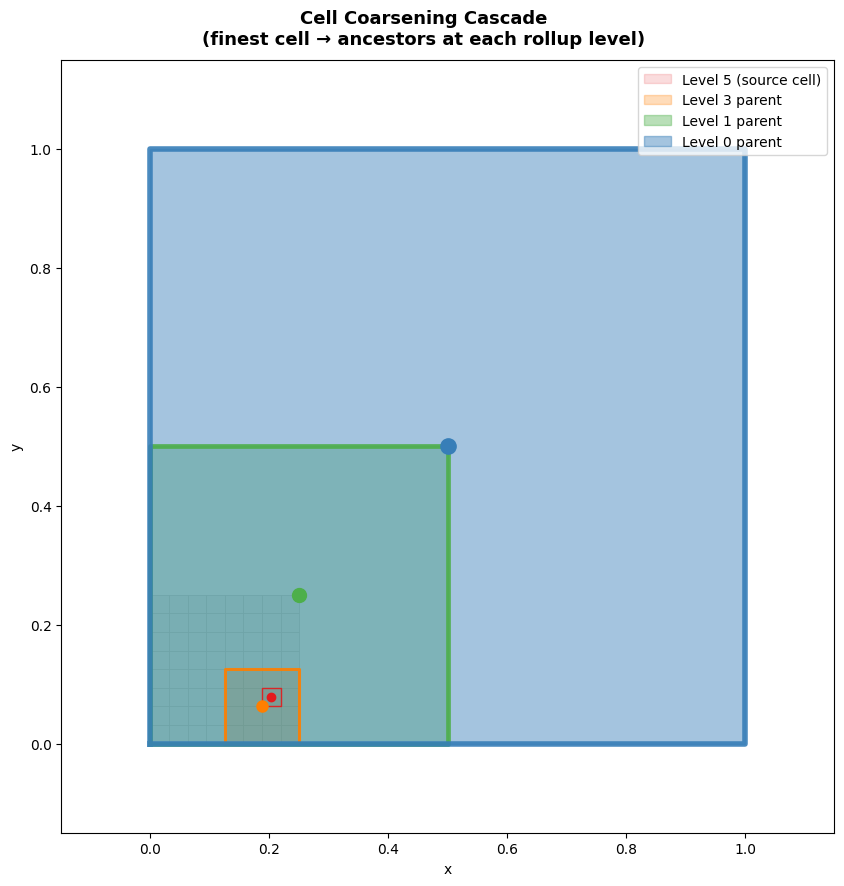

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Coarsening Cascade: pick one level-5 cell and show its parent chain
# Overlays the level-3, level-1, and level-0 ancestor boundaries on top.
# ══════════════════════════════════════════════════════════════════════════════

# Pick the level-5 cell with the highest patch_count to make the cascade vivid
finest_rows = spatial_data["pred_patch_label_agg"]
seed_cell   = max(finest_rows, key=lambda r: r[1])[0]

cascade_levels = [
    (seed_cell,                               5, "#e41a1c", "Level 5 (source cell)"),
    (grid.cell_to_parent(seed_cell, 3),       3, "#ff7f00", "Level 3 parent"),
    (grid.cell_to_parent(seed_cell, 1),       1, "#4daf4a", "Level 1 parent"),
    (grid.cell_to_parent(seed_cell, 0),       0, "#377eb8", "Level 0 parent"),
]

fig, ax = plt.subplots(figsize=(9, 9))
fig.suptitle("Cell Coarsening Cascade\n(finest cell → ancestors at each rollup level)",
             fontsize=13, fontweight="bold")

# Background: draw all level-5 cells in light grey so context is visible
for cell_id, _ in finest_rows:
    xs, ys = cell_polygon(cell_id)
    ax.fill(xs, ys, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.5)

# Overlay each ancestor with decreasing alpha so stacking is visible
for cell_id, level, color, label in cascade_levels:
    xs, ys = cell_polygon(cell_id)
    lw     = 1 + (5 - level) * 0.6          # thicker outline for coarser cells
    alpha  = 0.15 + (5 - level) * 0.06      # slightly more opaque for coarser
    ax.fill(xs, ys, color=color, alpha=alpha, label=label)
    ax.plot(xs, ys, color=color, linewidth=lw, alpha=0.9)
    # Mark the centroid
    cx, cy = grid.cell_to_point(cell_id)
    ax.plot(cx, cy, "o", color=color, markersize=6 + (5 - level))

# Set plot bounds based on the level-0 ancestor (coarsest = widest)
x0, x1, y0, y1 = view_bounds([(cascade_levels[-1][0], 1)], pad_frac=0.15)
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

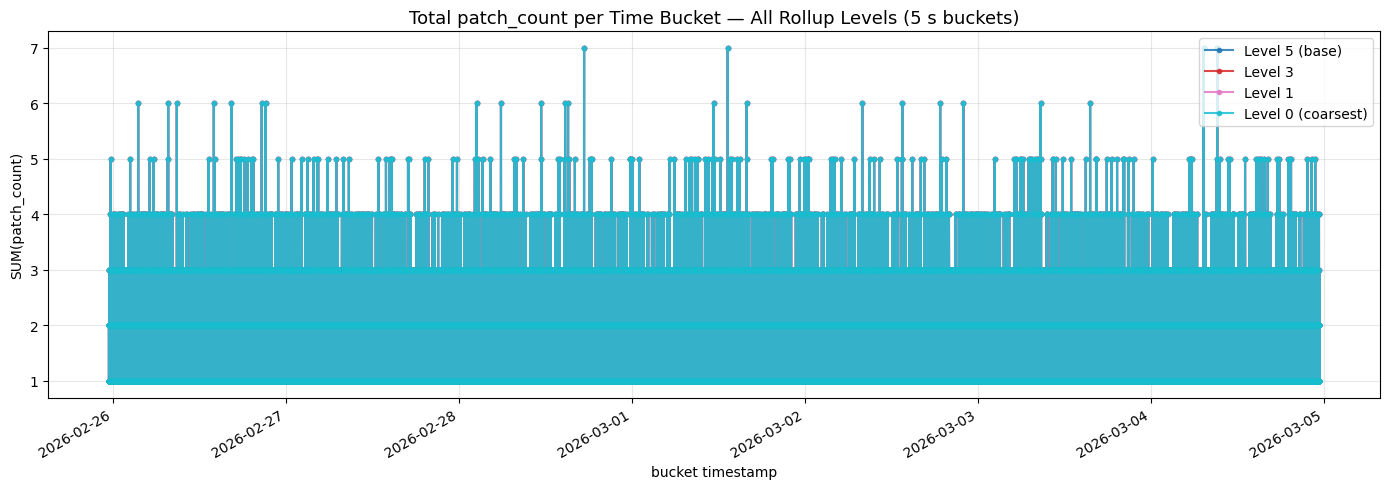

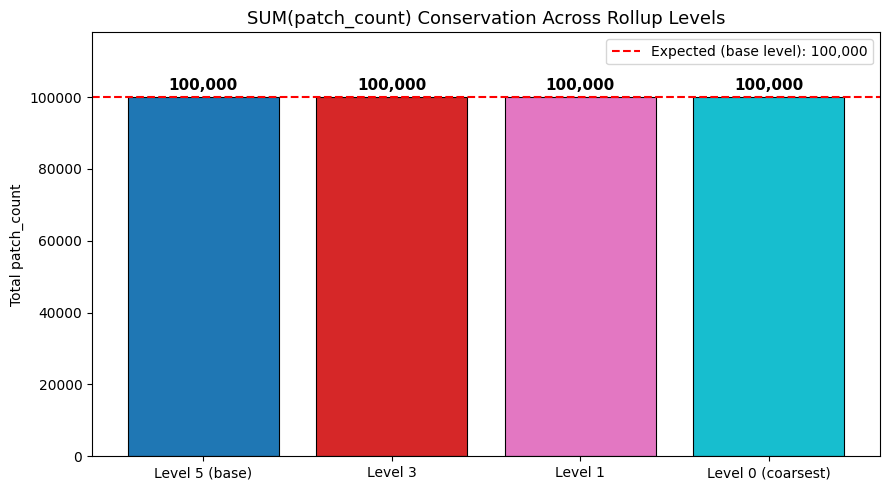

All visualizations rendered.


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Time Series: SUM(patch_count) per 5-second bucket, all four levels
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
colors_ts = plt.cm.tab10(np.linspace(0, 1, len(VIEWS)))

for (view, level, label), color in zip(VIEWS, colors_ts):
    rows = timeseries_data[view]
    if not rows:
        continue
    buckets = [r[0] for r in rows]
    totals  = [r[1] for r in rows]
    ax.plot(buckets, totals, marker="o", markersize=3, linewidth=1.5,
            label=label, color=color, alpha=0.85)

ax.set_title("Total patch_count per Time Bucket — All Rollup Levels (5 s buckets)", fontsize=13)
ax.set_xlabel("bucket timestamp")
ax.set_ylabel("SUM(patch_count)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot 4 — Conservation Bar Chart: same total at every level?
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

bar_labels  = [label for _, _, label in VIEWS]
bar_totals  = [sum(r[1] for r in spatial_data[view]) for view, _, _ in VIEWS]
bar_colors  = plt.cm.tab10(np.linspace(0, 1, len(VIEWS)))
expected    = bar_totals[0]

bars = ax.bar(bar_labels, bar_totals, color=bar_colors, edgecolor="black", linewidth=0.8)
for bar, total in zip(bars, bar_totals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + expected * 0.01,
            f"{total:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(expected, color="red", linestyle="--", linewidth=1.5,
           label=f"Expected (base level): {expected:,}")
ax.set_title("SUM(patch_count) Conservation Across Rollup Levels", fontsize=13)
ax.set_ylabel("Total patch_count")
ax.set_ylim(0, max(bar_totals) * 1.18)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

_vis_cur.close()
_vis_conn.close()
print("All visualizations rendered.")

In [39]:
# ── Verify the aggregate ─────────────────────────────────────────────────────
cur.execute("""
    SELECT
        bucket,
        pred_label,
        gt_label,
        grid_cell_id,
        patch_count
    FROM pred_patch_label_agg
    ORDER BY bucket DESC, grid_cell_id, pred_label, gt_label
    LIMIT 20;
""")
rows = cur.fetchall()
print(f"{'bucket':<25} {'pred':>4}  {'gt':>4}  {'cell':>6}  {'count':>6}")
print("-" * 55)
for r in rows:
    print(f"{str(r[0]):<25} {r[1]:>4}  {r[2]:>4}  {r[3]:>6}  {r[4]:>6}")

# Total distinct combinations
cur.execute("""
    SELECT COUNT(*) AS total_buckets,
           COUNT(DISTINCT (pred_label, gt_label, grid_cell_id)) AS distinct_combos
    FROM pred_patch_label_agg;
""")
total, combos = cur.fetchone()
print(f"\nTotal aggregate rows : {total:,}")
print(f"Distinct (pred, gt, cell) combinations : {combos:,}")

cur.close()
conn.close()

bucket                    pred    gt    cell   count
-------------------------------------------------------
2026-03-04 23:23:30+00:00    2     2  1441151880758558750       1
2026-03-04 23:23:30+00:00    2     2  1441151880758558760       1
2026-03-04 23:23:20+00:00    2     2  1441151880758558747       1
2026-03-04 23:23:15+00:00    1     1  1441151880758558730       1
2026-03-04 23:23:15+00:00    1     1  1441151880758558752       1
2026-03-04 23:23:00+00:00    4     4  1441151880758558730       1
2026-03-04 23:23:00+00:00    4     4  1441151880758558774       1
2026-03-04 23:22:50+00:00    0     0  1441151880758558726       1
2026-03-04 23:22:50+00:00    2     2  1441151880758558738       1
2026-03-04 23:22:50+00:00    4     4  1441151880758558779       1
2026-03-04 23:22:30+00:00    0     0  1441151880758558738       1
2026-03-04 23:22:30+00:00    0     0  1441151880758558760       1
2026-03-04 23:22:20+00:00    0     0  1441151880758558771       1
2026-03-04 23:22:05+00:00    3   